# 🔧 Industrial Predictive Maintenance System
### Phase 1 — Data Analysis & Machine Learning Pipeline

---

## Problem Statement

Rotating machinery — motors, pumps, compressors — depend on bearings to function. Bearing failures cause unplanned industrial downtime, costing thousands of dollars per hour.

Traditional maintenance strategies are either:
- **Reactive** — fix it after it breaks. Results in expensive unplanned downtime.
- **Time-based** — replace every N hours regardless of actual condition. Wastes parts that still have useful life.

**Predictive maintenance** is the solution: use vibration sensor data to detect bearing faults *early*, before failure occurs, and trigger maintenance only when it is actually needed. This project builds that system end-to-end.

---

## Dataset — CWRU Bearing Dataset

| Field | Details |
|---|---|
| **Source** | Case Western Reserve University (CWRU) — Bearing Data Center |
| **Official URL** | https://engineering.case.edu/bearingdatacenter |
| **Recognition** | Cited in 3,000+ research papers — the most widely used benchmark dataset for bearing fault detection in the world |
| **Equipment** | 2 HP Reliance Electric motor with SKF deep groove ball bearing (6205-2RS JEM) |
| **Sensor** | PCB Piezotronics accelerometer mounted directly on bearing housing |
| **Sampling Rate** | 12,000 samples/second (12 kHz) |
| **Load Condition** | 1 HP — 1772 RPM (this project) |
| **Fault Introduction** | Electro-discharge machining (EDM) at diameters: 0.007", 0.014", 0.021", 0.028" |

**Citation:**
> Smith, W.A. & Randall, R.B. (2015). *Rolling element bearing diagnostics using the Case Western Reserve University data: A benchmark study.* Mechanical Systems and Signal Processing, 64–65, 100–131.
> DOI: https://doi.org/10.1016/j.ymssp.2015.04.021

---

## Fault Classes

| Label | Class | Fault Location | Notes |
|---|---|---|---|
| 0 | **Normal** | — | Healthy bearing, no fault present |
| 1 | **Inner Race** | Inner raceway | Most common industrial bearing fault |
| 2 | **Ball** | Rolling element | Produces irregular impulse patterns |
| 3 | **Outer Race** | Outer raceway | Produces strong periodic impulses |

---

## Files Used in This Project

All files are from the **1 HP load condition**. `OR_014_1.mat` was excluded after EDA — its vibration signature was statistically identical to Normal, making it harmful for training.

| File | Label | Class | Fault Diameter |
|---|---|---|---|
| `normal_1.mat` | 0 | Normal | — |
| `IR_007_1.mat` | 1 | Inner Race | 0.007" |
| `IR_014_1.mat` | 1 | Inner Race | 0.014" |
| `IR_021_1.mat` | 1 | Inner Race | 0.021" |
| `IR_028_1.mat` | 1 | Inner Race | 0.028" |
| `ball_007_1.mat` | 2 | Ball | 0.007" |
| `ball_014_1.mat` | 2 | Ball | 0.014" |
| `ball_021_1.mat` | 2 | Ball | 0.021" |
| `ball_028_1.mat` | 2 | Ball | 0.028" |
| `OR_007_1.mat` | 3 | Outer Race | 0.007" |
| `OR_021_1.mat` | 3 | Outer Race | 0.021" |

**Total: 11 files — approximately 10 seconds of vibration data each at 12,000 Hz**

---

## Project Pipeline 

raw mat files

↓

01_eda.ipynb  → Visualize signals, FFT spectra, statistics, class distribution

↓

02_preprocessing.ipynb → Butterworth filter, windowing (1024 samples, 50% overlap), train/test split

↓

03_features.ipynb     → Extract 16 features (9 time-domain + 7 frequency-domain), StandardScaler, SMOTE

↓

04_modeling.ipynb     → Train 3 models, evaluate, SHAP explainability, hyperparameter tuning, save





## Additional Resources

| Resource | Link |
|---|---|
| Dataset download | https://engineering.case.edu/bearingdatacenter/download-data-file |
| Dataset paper | https://doi.org/10.1016/j.ymssp.2015.04.021 |
| Bearing fault fundamentals | https://www.skf.com/group/knowledge-hub/bearing-failures |


---

# 01 — Exploratory Data Analysis (EDA)

**Goal:** Load the raw vibration signals, understand their structure, and visualize the differences between normal and faulty bearings.

---
### What this notebook covers
1. Setup & imports  
2. Load all `.mat` files  
3. Dataset summary (class distribution)  
4. Raw signal visualization  
5. Signal comparison — Normal vs Faulty  
6. Frequency spectrum analysis (FFT)  
7. Statistical summary per class  
8. Key observations & conclusions  

---
## 1. Setup & Imports

In [1]:
import sys
import os
sys.path.append(os.path.abspath('../src'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.fft import rfft, rfftfreq
from scipy.stats import kurtosis,skew
from loader import load_cwru_mat,build_dataset,summarize_dataset,get_label_name
from collections import Counter



print('Done')

Done


In [2]:
plt.rcParams['figure.dpi']= 120
plt.rcParams['figure.facecolor']= '#0f0f11'
plt.rcParams['axes.facecolor']='#0f0f11'
plt.rcParams['axes.edgecolor']= '#2a2a30'
plt.rcParams['axes.labelcolor'] ='#ccccdd'
plt.rcParams['xtick.color']='#7a7a8e'
plt.rcParams['ytick.color']='#7a7a8e'
plt.rcParams['text.color']= '#e8e8f0'
plt.rcParams['grid.color'] = '#1e2330'
plt.rcParams['grid.linewidth']= 0.6

CLASS_COLORS = {
    0: '#4fbe97',   # Normal      — green
    1: '#3d6aff',   # Inner Race  — blue
    2: '#f0a147',   # Ball        — orange
    3: '#c17cff',   # Outer Race  — purple
}

---
## 2. Load Dataset

In [3]:
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR     = os.path.join(PROJECT_ROOT, 'data', 'raw')
REPORTS_DIR  = os.path.join(PROJECT_ROOT, 'reports')
os.makedirs(REPORTS_DIR, exist_ok=True)
FS=12000   # sampling rate in Hz 

records= build_dataset(DATA_DIR)


summarize_dataset(records)


✓ Loaded 12 files successfully.

── Dataset Summary ──────────────────────────
  Total files loaded : 12
  Signal length range: 121,351 – 483,903 samples

  Class distribution:
    0 (Normal      ):   1 files  (8.3%)  █
    1 (Inner Race  ):   4 files  (33.3%)  ████
    2 (Ball        ):   4 files  (33.3%)  ████
    3 (Outer Race  ):   3 files  (25.0%)  ███
─────────────────────────────────────────────



In [4]:
r = records[7]
print(f"File:{r['file']}")
print(f"Label :{r['label']} ({get_label_name(r['label'])})")
print(f"Signal:{len(r['signal']):,} samples")
print(f"Duration: {len(r['signal'])/FS:.2f} seconds at {FS} Hz")
print(f"Min : {r['signal'].min():.6f}")
print(f"Max :{r['signal'].max():.6f}")
print(f"Mean :{r['signal'].mean():.6f}")
print(f"Std : {r['signal'].std():.6f}")

File:ball_007_1.mat
Label :2 (Ball)
Signal:121,410 samples
Duration: 10.12 seconds at 12000 Hz
Min : -0.659649
Max :0.639670
Mean :0.003892
Std : 0.139014


---
## 3. Class Distribution

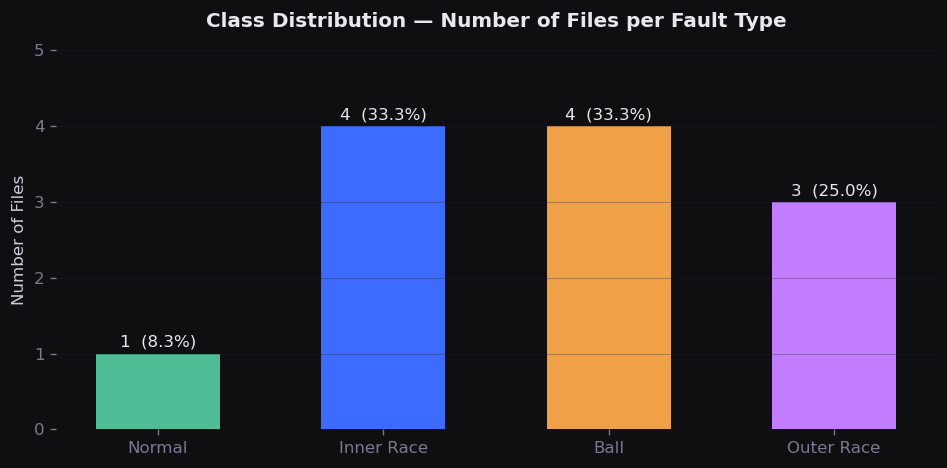

Saved → reports/01_class_distribution.png


In [5]:
labels= [r['label'] for r in records]
label_counts=Counter(labels)
total = len(records)

fig,ax =plt.subplots(figsize=(8, 4))

classes= sorted(label_counts.keys())
counts = [label_counts[c] for c in classes]
names =[get_label_name(c) for c in classes]
colors=[CLASS_COLORS[c] for c in classes]

bars=   ax.bar(names, counts, color=colors, edgecolor='none', width=0.55)

for bar,count in zip(bars,counts):
    pct = count/ total *100
    ax.text(bar.get_x() +bar.get_width()/2,
            bar.get_height() + 0.05,
            f'{count}  ({pct:.1f}%)',
            ha='center', va='bottom', fontsize=10, color='#e8e8f0')

ax.set_title('Class Distribution — Number of Files per Fault Type',
             fontsize=12, fontweight='bold',pad=14)
ax.set_ylabel('Number of Files')
ax.set_ylim(0, max(counts) * 1.25)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right','left','bottom']].set_visible(False)

plt.tight_layout()
plt.savefig(r'C:\Users\My Pc\Downloads\predictive-maintenance\reports/01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → reports/01_class_distribution.png')

> **Observation:** Severe file-level imbalance — only 1 Normal file vs 3–4 fault files.
> However, the Normal file is 40s long vs ~10s per fault file, yielding ~944 Normal windows
> vs ~236 per fault file. Window-level balance is acceptable

---
## 4. Raw Signal Visualization


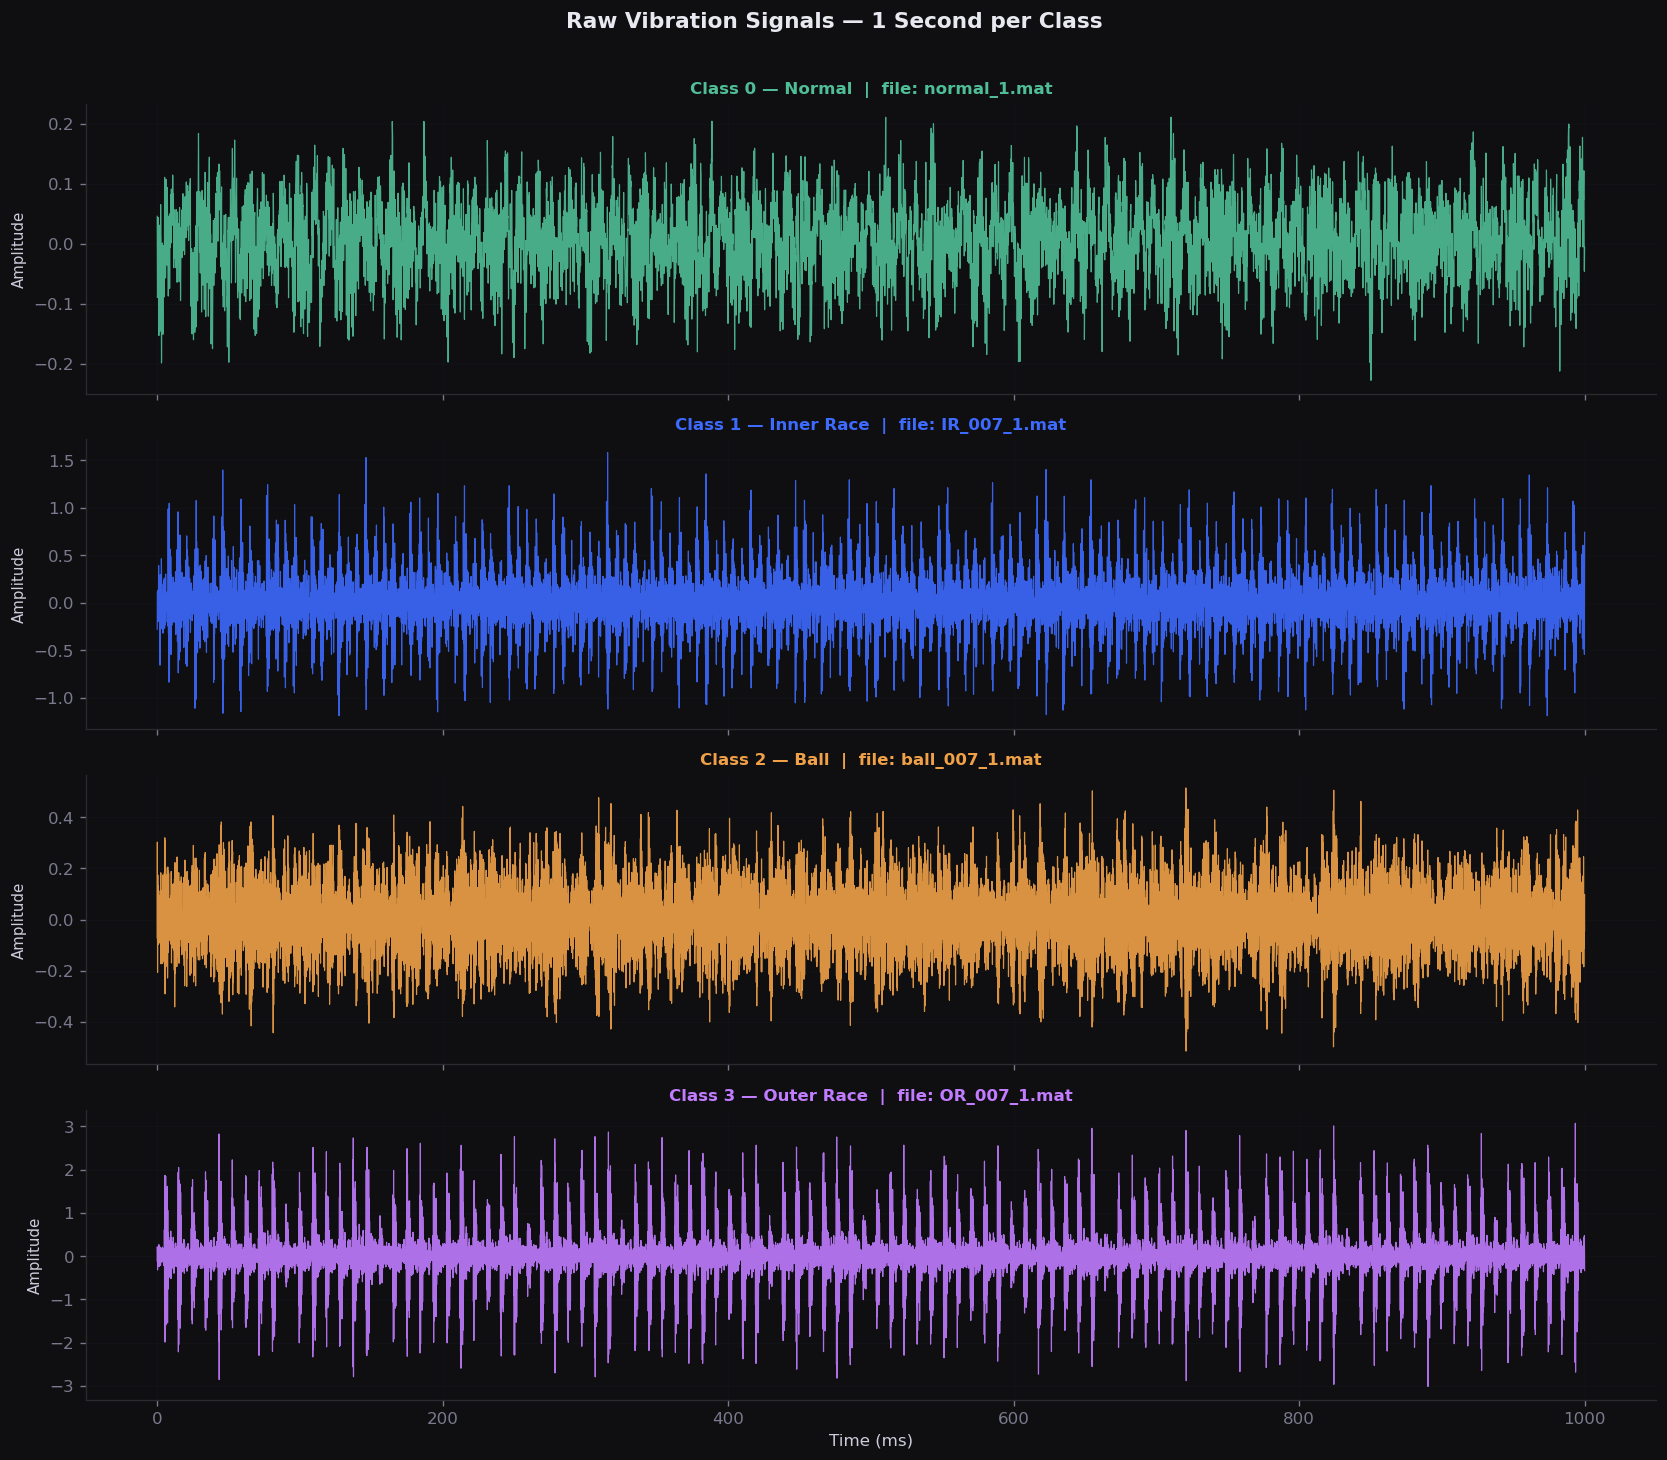

Saved


In [6]:
def get_one_per_class(records):
    seen   = set()
    result = {}
    for r in records:
        if r['label'] not in seen:
            result[r['label']] = r
            seen.add(r['label'])
    return result

representatives = get_one_per_class(records)

N_SHOW=FS  
t =np.arange(N_SHOW) / FS *1000   

fig, axes= plt.subplots(len(representatives), 1,
                          figsize=(14, 3 * len(representatives)),
                          sharex=True)

if len(representatives)==1:
    axes = [axes]

for ax, (label, rec) in zip(axes, sorted(representatives.items())):
    signal= rec['signal'][:N_SHOW]
    color= CLASS_COLORS[label]
    ax.plot(t, signal, color=color, linewidth=0.7, alpha=0.9)
    ax.set_title(f"Class {label} — {get_label_name(label)}  |  file: {rec['file']}",
                 fontsize=10, fontweight='bold', color=color)
    ax.set_ylabel('Amplitude', fontsize=9)
    ax.grid(True, alpha=0.2)
    ax.spines[['top','right']].set_visible(False)

axes[-1].set_xlabel('Time (ms)', fontsize=10)
fig.suptitle('Raw Vibration Signals — 1 Second per Class',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(r'C:\Users\My Pc\Downloads\predictive-maintenance\reports/02_raw_signals.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved')

> **Observation:** Amplitude envelopes already visually separate the classes at 1-second scale.
> Normal: ±0.2, Ball: ±0.4, Inner Race: ±1.5, Outer Race: ±3.0. Outer Race shows periodic 
> burst structure visible even at this compressed view. Ball resembles amplified Normal —
> confirming it will be the hardest class to distinguish without spectral features.

---
## 5. Normal vs Faulty — Side-by-Side Comparison
Zoom in to 100ms to see the impulse patterns in faulty bearings.

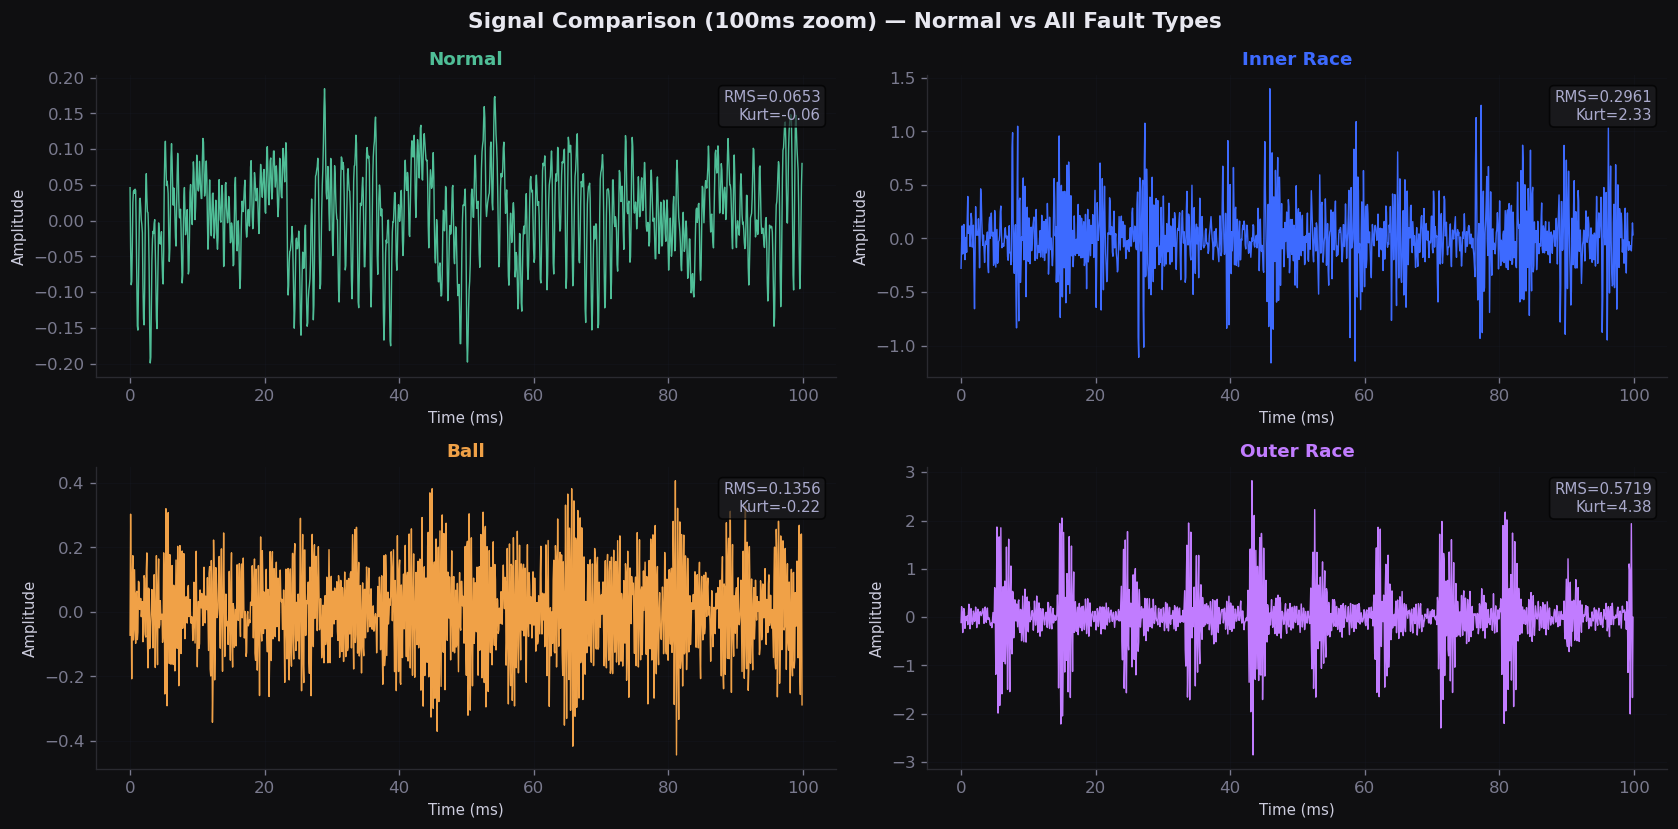

Saved 


In [8]:
N_ZOOM = int(FS * 0.1)   
t_zoom = np.arange(N_ZOOM)/FS *1000

fig, axes = plt.subplots(2, 2,figsize=(14, 7))
axes = axes.flatten()

for ax, (label, rec) in zip(axes,sorted(representatives.items())):
    signal = rec['signal'][:N_ZOOM]
    color  = CLASS_COLORS[label]

    ax.plot(t_zoom, signal, color=color, linewidth=0.85)
    ax.set_title(f"{get_label_name(label)}",
                 fontsize=11, fontweight='bold', color=color)
    ax.set_xlabel('Time (ms)', fontsize=9)
    ax.set_ylabel('Amplitude', fontsize=9)
    rms  = np.sqrt(np.mean(signal**2))
    kurt = kurtosis(signal)
    ax.text(0.98, 0.95,
            f'RMS={rms:.4f}\nKurt={kurt:.2f}',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=9, color='#aaaacc',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#1e1e22', alpha=0.7))

    ax.grid(True, alpha=0.2)
    ax.spines[['top','right']].set_visible(False)

fig.suptitle('Signal Comparison (100ms zoom) — Normal vs All Fault Types',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\My Pc\Downloads\predictive-maintenance\reports/03_signal_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved ')

> **Observation:** Time-domain kurtosis tells a nuanced story. Outer Race (Kurt=4.38) shows
> clear periodic impulses — textbook fault behavior. Inner Race (Kurt=2.33) and Ball (Kurt=−0.22)
> from the mildest severity files (007) show near-Gaussian behavior in time domain.
> Kurtosis is severity-dependent, not just fault-type-dependent.

---
## 6. Frequency Spectrum Analysis (FFT)


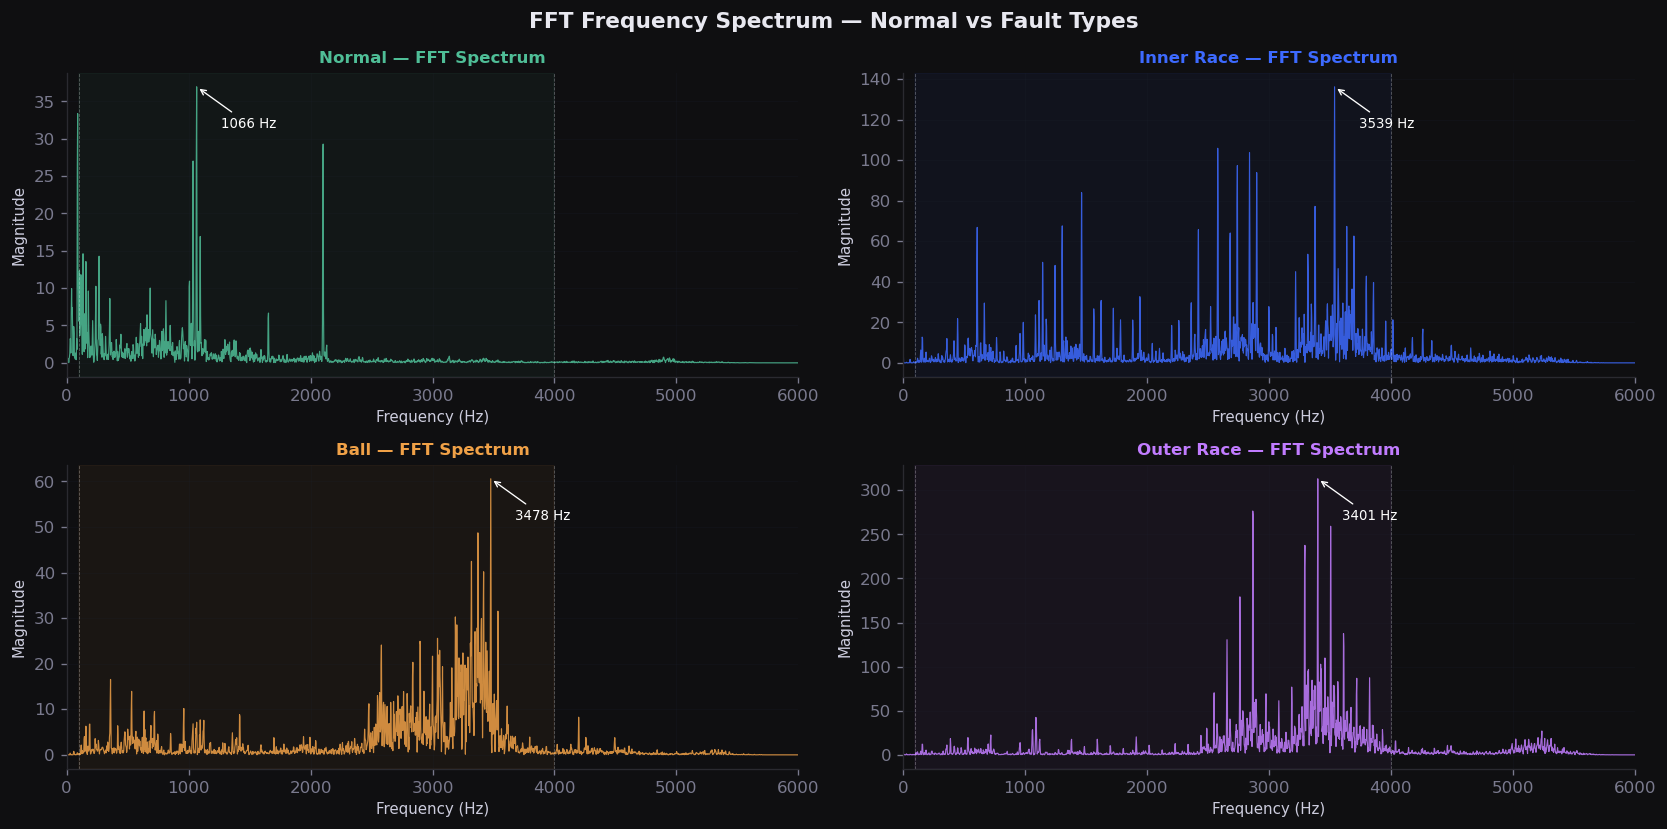

Saved


In [10]:
def compute_fft(signal, fs=12000, n_samples=4096):
    """Compute FFT magnitude spectrum for a signal segment."""
    segment= signal[:n_samples]
    window =np.hanning(len(segment))
    fft_mag =np.abs(rfft(segment * window))
    freqs   =rfftfreq(len(segment), d=1.0/fs)
    return freqs,fft_mag

fig,axes = plt.subplots(2,2, figsize=(14, 7))
axes =axes.flatten()

for ax,(label, rec) in zip(axes,sorted(representatives.items())):
    freqs,fft_mag =compute_fft(rec['signal'], fs=FS)
    color= CLASS_COLORS[label]
    ax.plot(freqs, fft_mag, color=color, linewidth=0.7, alpha=0.85)
    ax.axvspan(100, 4000, color=color, alpha=0.05, label='Fault band (100–4000 Hz)')
    ax.axvline(100,  color='#ffffff', linewidth=0.5, linestyle='--', alpha=0.3)
    ax.axvline(4000, color='#ffffff', linewidth=0.5, linestyle='--', alpha=0.3)

    dom_freq= freqs[np.argmax(fft_mag)]
    dom_mag = np.max(fft_mag)
    ax.annotate(f'{dom_freq:.0f} Hz',
                xy=(dom_freq, dom_mag),
                xytext=(dom_freq + 200,dom_mag *0.85),
                fontsize=8,color='#ffffff',
                arrowprops=dict(arrowstyle='->',color='#ffffff', lw=0.8))

    ax.set_title(f"{get_label_name(label)} — FFT Spectrum",
                 fontsize=10, fontweight='bold', color=color)
    ax.set_xlabel('Frequency (Hz)', fontsize=9)
    ax.set_ylabel('Magnitude', fontsize=9)
    ax.set_xlim(0, FS/2)
    ax.grid(True, alpha=0.2)
    ax.spines[['top','right']].set_visible(False)

fig.suptitle('FFT Frequency Spectrum — Normal vs Fault Types',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\My Pc\Downloads\predictive-maintenance\reports/04_fft_spectra.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved')

 **Observation — IMPORTANT:** Dominant fault frequency peaks (IR: 3539 Hz, Ball: 3478 Hz,
 OR: 3401 Hz)
 
 Outer Race spectrum magnitude (300) is 8–10× that of Normal (35), making it the most
 detectable class by FFT energy alone.

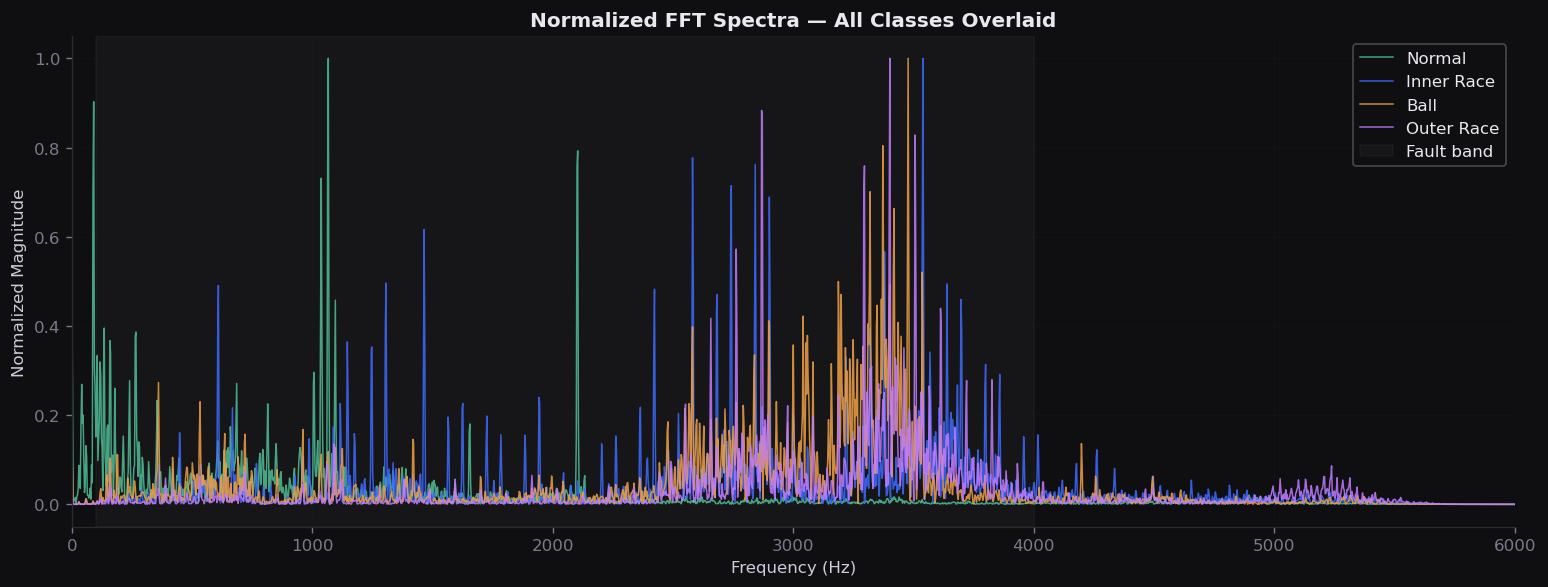

Saved 


In [11]:
fig,ax = plt.subplots(figsize=(13, 5))

for label, rec in sorted(representatives.items()):
    freqs, fft_mag = compute_fft(rec['signal'], fs=FS)
    fft_norm = fft_mag / (np.max(fft_mag) + 1e-10)
    ax.plot(freqs, fft_norm,
            color=CLASS_COLORS[label],
            linewidth=0.9,alpha=0.85,
            label=get_label_name(label))

ax.axvspan(100,4000, color='#ffffff', alpha=0.03, label='Fault band')
ax.set_title('Normalized FFT Spectra — All Classes Overlaid',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Frequency (Hz)', fontsize=10)
ax.set_ylabel('Normalized Magnitude', fontsize=10)
ax.set_xlim(0, FS/2)
ax.legend(fontsize=10, framealpha=0.3)
ax.grid(True, alpha=0.2)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(r'C:\Users\My Pc\Downloads\predictive-maintenance\reports/05_fft_overlay.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved ')

> **Observation:** A clear spectral boundary exists near 2000 Hz. Normal energy dominates
> below 2000 Hz; all fault classes dominate above 2500 Hz. A single feature — ratio of 
> high-frequency energy (>2000 Hz) to total signal energy — should be highly discriminative
> for Normal vs Fault binary detection. The three fault classes peak within ~140 Hz of each
> other (3401–3539 Hz), making peak frequency alone insufficient to distinguish fault type.

---
## 7. Statistical Summary per Class


In [12]:
stats_rows= []

for rec in records:
    sig = rec['signal']
    stats_rows.append({
        'Label':rec['label'],
        'Class': get_label_name(rec['label']),
        'File': rec['file'],
        'Length': len(sig),
        'RMS': round(np.sqrt(np.mean(sig**2)), 6),
        'Kurtosis':round(kurtosis(sig), 4),
        'Skewness': round(skew(sig), 4),
        'Peak':round(np.max(np.abs(sig)), 6),
        'Std':round(np.std(sig), 6),
        'PeakToPeak':round(np.max(sig) - np.min(sig), 6),
    })

df_stats= pd.DataFrame(stats_rows)

print('Per-File Statistics')
print(df_stats.to_string(index=False))

Per-File Statistics
 Label      Class           File  Length      RMS  Kurtosis  Skewness      Peak      Std  PeakToPeak
     1 Inner Race   IR_007_1.mat  121991 0.292892    2.5423    0.1304  1.580819 0.292835    2.983771
     1 Inner Race   IR_014_1.mat  121846 0.165514   19.0843    0.0030  2.030114 0.165475    4.031640
     1 Inner Race   IR_021_1.mat  121556 0.441838    4.6667    0.2563  3.686059 0.441827    6.970091
     1 Inner Race   IR_028_1.mat  121351 0.837560    0.1956    0.0988  3.930654 0.837520    7.647686
     3 Outer Race   OR_007_1.mat  122426 0.591947    4.5950    0.0334  3.112257 0.591933    6.124210
     3 Outer Race   OR_014_1.mat  122136 0.093579   -0.0597    0.0089  0.401644 0.093528    0.797482
     3 Outer Race   OR_021_1.mat  121991 0.561378   18.9707    0.1280  6.207052 0.561367   12.319892
     2       Ball ball_007_1.mat  121410 0.139068   -0.0362    0.0075  0.659649 0.139014    1.299319
     2       Ball ball_014_1.mat  122136 0.140878    5.8371    0.0157  

In [13]:
df_grouped = df_stats.groupby('Class')[['RMS','Kurtosis','Skewness','Peak','Std']].mean().round(4)

print('── Mean Statistics per Class ────────────────────────────')
print(df_grouped.to_string())
print()
print('Key insight: Kurtosis is highest for faulty classes.')
print('Normal bearing kurtosis ≈ 0–3 | Faulty can exceed 10–30')

── Mean Statistics per Class ────────────────────────────
               RMS  Kurtosis  Skewness    Peak     Std
Class                                                 
Ball        0.6097    3.2796    0.0161  3.7870  0.6097
Inner Race  0.4345    6.6222    0.1221  2.8069  0.4344
Normal      0.0664   -0.0694   -0.1730  0.3459  0.0652
Outer Race  0.4156    7.8353    0.0568  3.2403  0.4156

Key insight: Kurtosis is highest for faulty classes.
Normal bearing kurtosis ≈ 0–3 | Faulty can exceed 10–30


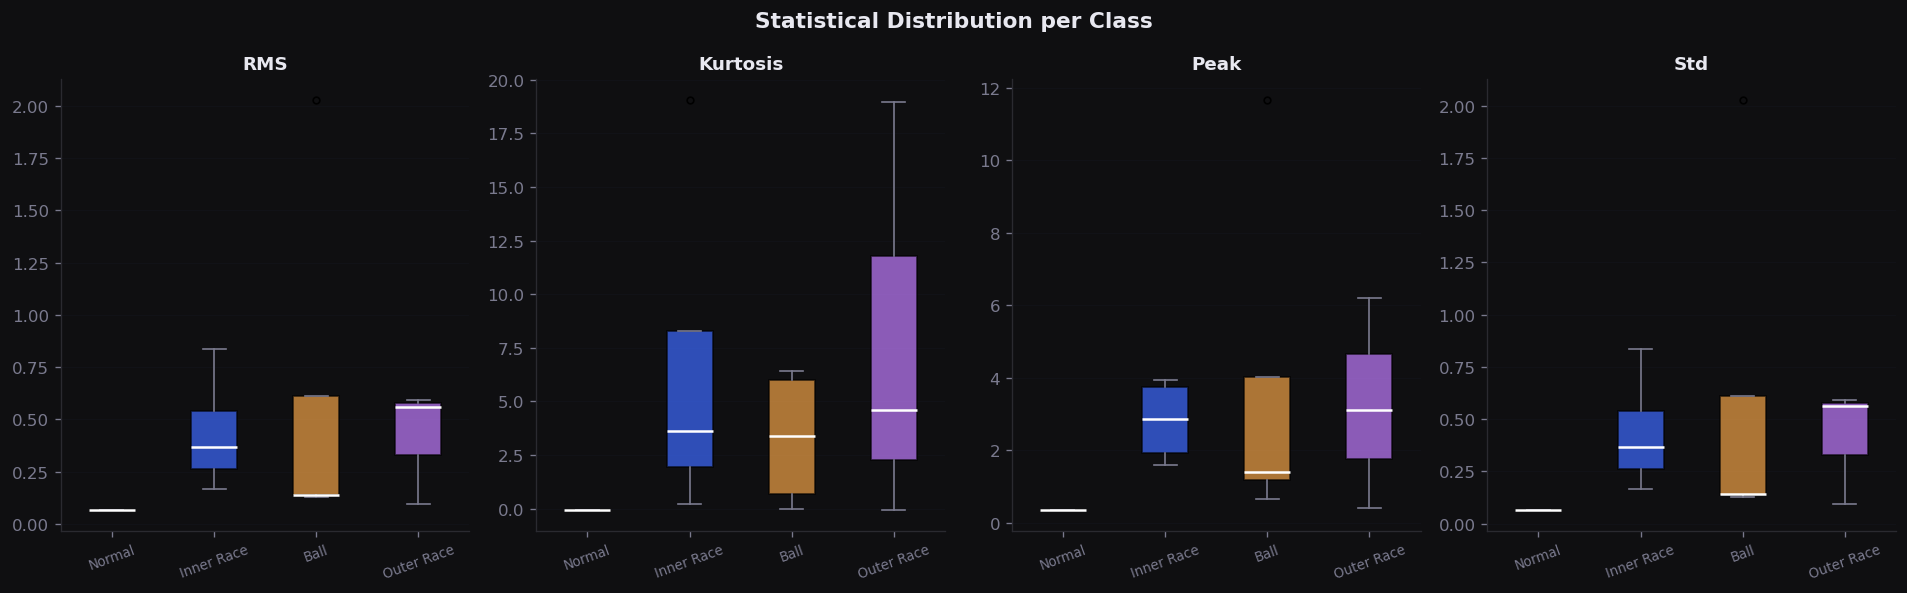

Saved


In [14]:
metrics_to_plot = ['RMS', 'Kurtosis', 'Peak', 'Std']

fig,axes = plt.subplots(1, 4, figsize=(16, 5))

for ax,metric in zip(axes, metrics_to_plot):
    class_order = ['Normal', 'Inner Race', 'Ball', 'Outer Race']
    palette= {name: CLASS_COLORS[i]
                   for i, name in enumerate(['Normal','Inner Race','Ball','Outer Race'])}

    data_to_plot = [
        df_stats[df_stats['Class'] == cls][metric].values
        for cls in class_order
        if cls in df_stats['Class'].values
    ]
    labels_present = [
        cls for cls in class_order
        if cls in df_stats['Class'].values
    ]
    colors_present =[palette[cls] for cls in labels_present]

    bp = ax.boxplot(data_to_plot, patch_artist=True,
                    medianprops=dict(color='white', linewidth=1.5),
                    whiskerprops=dict(color='#7a7a8e'),
                    capprops=dict(color='#7a7a8e'),
                    flierprops=dict(marker='o', color='#7a7a8e', markersize=4))

    for patch, color in zip(bp['boxes'], colors_present):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_xticklabels(labels_present, rotation=20, fontsize=8)
    ax.set_title(metric, fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.2)
    ax.spines[['top','right']].set_visible(False)

fig.suptitle('Statistical Distribution per Class',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\My Pc\Downloads\predictive-maintenance\reports/06_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved')

> **Observation:** RMS and Std cleanly separate Normal from all fault types (no overlap).
> Kurtosis shows high within-class variance driven by fault severity differences — the 
> per-file table shows kurtosis ranging from 0.2 to 19.0 within the Inner Race class alone.
> No single time-domain feature reliably separates all four classes. 

---
## 8. Amplitude Distribution (Histogram)

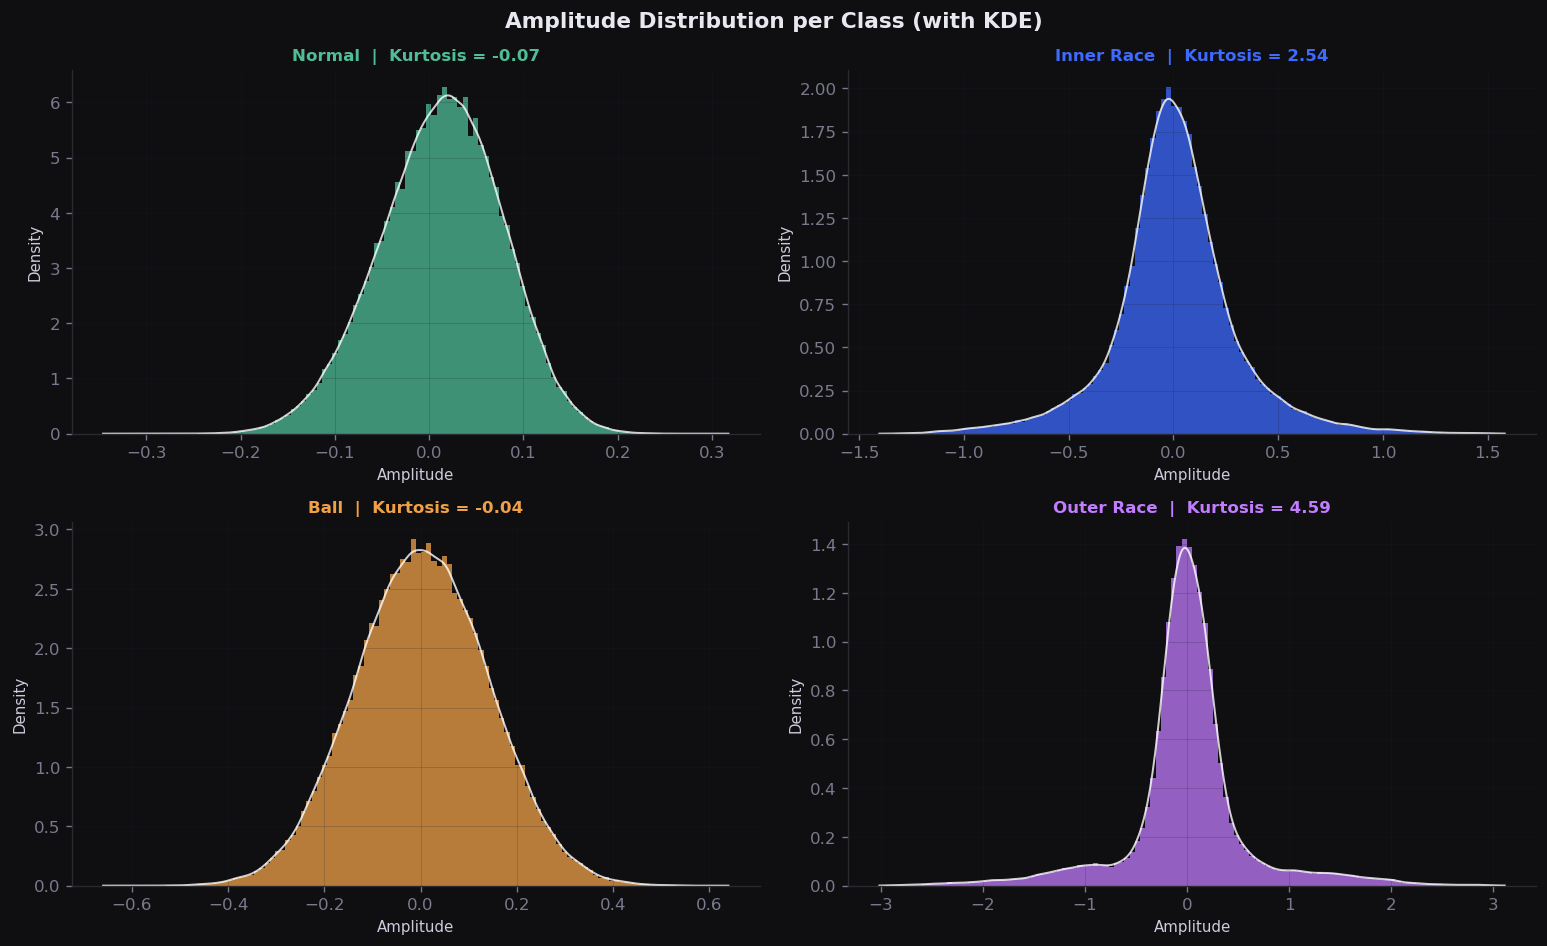

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for ax, (label, rec) in zip(axes, sorted(representatives.items())):
    sig   = rec['signal']
    color = CLASS_COLORS[label]

    ax.hist(sig, bins=120, color=color, alpha=0.75, edgecolor='none', density=True)

   
    from scipy.stats import gaussian_kde
    kde  = gaussian_kde(sig)
    x    = np.linspace(sig.min(), sig.max(), 500)
    ax.plot(x, kde(x), color='white', linewidth=1.2, alpha=0.8)

    kurt_val = kurtosis(sig)
    ax.set_title(f"{get_label_name(label)}  |  Kurtosis = {kurt_val:.2f}",
                 fontsize=10, fontweight='bold', color=color)
    ax.set_xlabel('Amplitude', fontsize=9)
    ax.set_ylabel('Density', fontsize=9)
    ax.grid(True, alpha=0.2)
    ax.spines[['top','right']].set_visible(False)

fig.suptitle('Amplitude Distribution per Class (with KDE)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\My Pc\Downloads\predictive-maintenance\reports/07_amplitude_distributions.png', dpi=150, bbox_inches='tight')
plt.show()



> **Observation — Amplitude Distributions:**
>
> Normal (Kurt=−0.07) and Ball (Kurt=−0.04) are statistically indistinguishable by 
> amplitude distribution shape alone. Both are near-perfect Gaussians. The Ball class
> representative here is `ball_007_1.mat` (mildest severity) — higher severity Ball files
> reach kurtosis 5.8–6.4 and do show heavy tails. This plot is severity-dependent and
> should not be interpreted as "Ball faults are undetectable."
>
> Outer Race (Kurt=4.59) shows the clearest leptokurtic signature — sharp central peak
> with tails extending to ±3.0, vs Normal's ±0.3. This 10× amplitude range difference
> combined with the distribution shape makes Outer Race the most detectable class.
>
> Inner Race (Kurt=2.54) shows mild heavy tails beginning to form — a transition state
> between Gaussian (healthy) and strongly leptokurtic (severe fault).


---
## 9. Signal Length Check


In [16]:
WINDOW_SIZE = 1024
OVERLAP= 0.5
STEP = int(WINDOW_SIZE * (1 - OVERLAP))

print(f'Window size : {WINDOW_SIZE} samples ({WINDOW_SIZE/FS*1000:.1f} ms)')
print(f'Overlap: {int(OVERLAP*100)}%')
print(f'Step: {STEP} samples')
print()
print(f'{"File":<25} {"Samples":>10} {"Duration":>10} {"Windows":>10}')
print('─'*60)

total_windows = 0
for rec in records:
    n_samples = len(rec['signal'])
    n_windows = (n_samples - WINDOW_SIZE)// STEP + 1
    duration  = n_samples / FS
    total_windows +=n_windows
    print(f"{rec['file']:<25} {n_samples:>10,} {duration:>9.1f}s {n_windows:>10,}")

print('─' *60)
print(f'Total windows for ML: {total_windows:,}')

Window size : 1024 samples (85.3 ms)
Overlap: 50%
Step: 512 samples

File                         Samples   Duration    Windows
────────────────────────────────────────────────────────────
IR_007_1.mat                 121,991      10.2s        237
IR_014_1.mat                 121,846      10.2s        236
IR_021_1.mat                 121,556      10.1s        236
IR_028_1.mat                 121,351      10.1s        236
OR_007_1.mat                 122,426      10.2s        238
OR_014_1.mat                 122,136      10.2s        237
OR_021_1.mat                 121,991      10.2s        237
ball_007_1.mat               121,410      10.1s        236
ball_014_1.mat               122,136      10.2s        237
ball_021_1.mat               121,701      10.1s        236
ball_028_1.mat               121,351      10.1s        236
normal_1.mat                 483,903      40.3s        944
────────────────────────────────────────────────────────────
Total windows for ML: 3,546


---
## 10. EDA Summary & Key Observations

> **Observation — Anomalous files:**
> - `OR_014_1.mat`: RMS=0.094, Kurt=−0.06 → statistically identical to Normal.
> - `IR_028_1.mat`: Kurt=0.20 → near-Gaussian despite being the most severe inner race fault.
>   Severe faults exhibit continuous vibration rather than discrete impacts, suppressing kurtosis.
> - `ball_028_1.mat`: RMS=2.03, Peak=11.67 → extreme outlier, 15× other Ball files. Confirm
>   this represents valid test data and not a sensor artifact before including in training.
>
> **Mean statistics confirm:** Outer Race has the highest mean kurtosis (7.84), Inner Race 
> second (6.62), Ball third (3.28). Normal is near zero (−0.07). 